In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/batthulavinay/indian-food-nutrition/Indian_Food_Nutrition_Processed.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
nutri_df = pd.read_csv('/kaggle/input/datasets/batthulavinay/indian-food-nutrition/Indian_Food_Nutrition_Processed.csv')

In [4]:
nutri_df.head()

,Dish Name,Calories (kcal),Carbohydrates (g),Protein (g),Fats (g),Free Sugar (g),Fibre (g),Sodium (mg),Calcium (mg),Iron (mg),Vitamin C (mg),Folate (µg)
0,Hot tea (Garam Chai),16.14,2.58,0.39,0.53,2.58,0.00,3.12,14.20,0.02,0.50,1.80
1,Instant coffee,23.16,3.65,0.64,0.75,3.62,0.00,4.92,20.87,0.06,1.51,5.60
2,Espreso coffee,51.54,6.62,1.75,2.14,6.53,0.00,13.98,58.10,0.15,1.51,5.53
3,Iced tea,10.34,2.70,0.03,0.01,2.70,0.00,0.23,1.18,0.02,5.95,1.28
4,Raw mango drink (Aam panna),35.92,9.05,0.16,0.03,7.49,0.61,79.82,7.08,0.14,45.30,14.05


In [5]:
# Basic Info
print("Shape of Dataset:", nutri_df.shape)


Shape of Dataset: (1014, 12)


In [6]:
print("\nColumn Names:\n", nutri_df.columns.tolist())


Column Names:
 ['Dish Name', 'Calories (kcal)', 'Carbohydrates (g)', 'Protein (g)', 'Fats (g)', 'Free Sugar (g)', 'Fibre (g)', 'Sodium (mg)', 'Calcium (mg)', 'Iron (mg)', 'Vitamin C (mg)', 'Folate (µg)']


In [7]:
print("\nData Types:\n", nutri_df.dtypes)


Data Types:
 Dish Name             object
Calories (kcal)      float64
Carbohydrates (g)    float64
Protein (g)          float64
Fats (g)             float64
Free Sugar (g)       float64
Fibre (g)            float64
Sodium (mg)          float64
Calcium (mg)         float64
Iron (mg)            float64
Vitamin C (mg)       float64
Folate (µg)          float64
dtype: object


In [8]:
print("\nMissing Values:\n", nutri_df.isnull().sum())


Missing Values:
 Dish Name             0
Calories (kcal)       0
Carbohydrates (g)     0
Protein (g)           0
Fats (g)              0
Free Sugar (g)        0
Fibre (g)             0
Sodium (mg)           0
Calcium (mg)          0
Iron (mg)             0
Vitamin C (mg)       82
Folate (µg)          82
dtype: int64


In [9]:
# Summary Statistics
print("\nSummary Statistics:\n")
display(nutri_df.describe())




Summary Statistics:



,Calories (kcal),Carbohydrates (g),Protein (g),Fats (g),Free Sugar (g),Fibre (g),Sodium (mg),Calcium (mg),Iron (mg),Vitamin C (mg),Folate (µg)
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,932.000000,932.000000
mean,233.735897,18.354004,4.753008,16.267584,8.824832,1.962485,481.076755,59.877091,1.136953,14.985172,41.920000
std,187.599467,16.745936,3.442746,20.452322,12.378324,2.771622,1750.646423,67.441463,1.520863,26.619886,54.147515
min,6.610000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,101.180000,5.582500,2.100000,4.030000,1.152500,0.590000,41.910000,18.237500,0.460000,1.257500,11.955000
50%,174.920000,11.925000,3.990000,9.095000,2.780000,1.325000,101.290000,40.680000,0.830000,5.400000,24.770000
75%,315.845000,26.870000,6.602500,17.085000,11.822500,2.347500,196.605000,79.385000,1.290000,18.222500,49.100000
max,839.330000,86.530000,21.550000,90.450000,85.570000,35.710000,14174.590000,631.820000,20.570000,382.640000,550.520000


# 📊 Dataset Overview

- **Total dishes:** 1,014  
- **Total columns:** 12  
- **All nutrition columns are numeric (float64)**  
- **No missing values except:**
  - Vitamin C (mg): 82 missing  
  - Folate (µg): 82 missing  

This is a well-structured dataset and mostly clean.


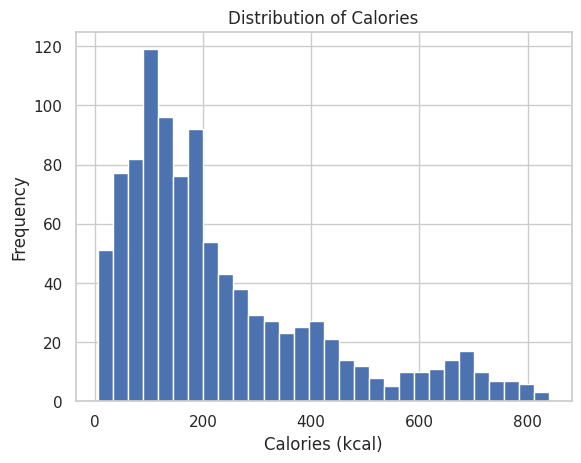

In [10]:
# Calories Distribution
plt.figure()
plt.hist(nutri_df['Calories (kcal)'], bins=30)
plt.title("Distribution of Calories")
plt.xlabel("Calories (kcal)")
plt.ylabel("Frequency")
plt.show()

## 🔥 Calories
- Most dishes fall between **50–300 kcal**
- Distribution is **right-skewed**
- Few extreme high-calorie foods go above **700–800 kcal**
- Indicates presence of deep-fried or heavy dishes

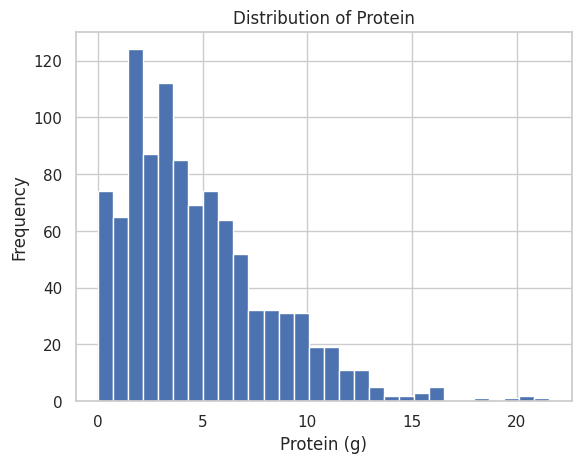

In [11]:
# Protein Distribution
plt.figure()
plt.hist(nutri_df['Protein (g)'], bins=30)
plt.title("Distribution of Protein")
plt.xlabel("Protein (g)")
plt.ylabel("Frequency")
plt.show()

## 🍗 Protein
- Majority dishes have **2–8g protein**
- Very few exceed **15g**
- Suggests most Indian dishes are **not high-protein**


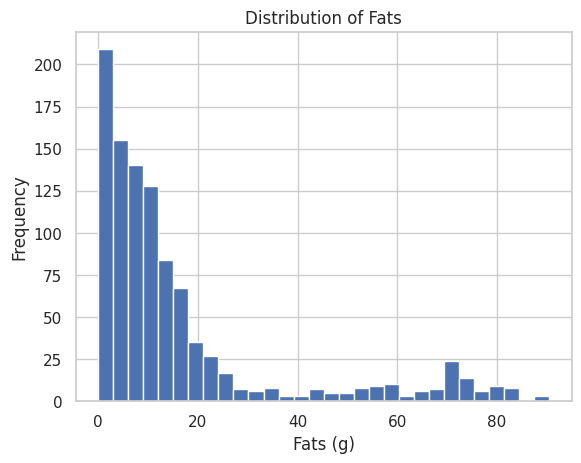

In [12]:
# Fats Distribution
plt.figure()
plt.hist(nutri_df['Fats (g)'], bins=30)
plt.title("Distribution of Fats")
plt.xlabel("Fats (g)")
plt.ylabel("Frequency")
plt.show()

## 🧈 Fats
- Many dishes under **20g fat**
- Strong right skew
- Some extreme outliers reach **80–90g fat**

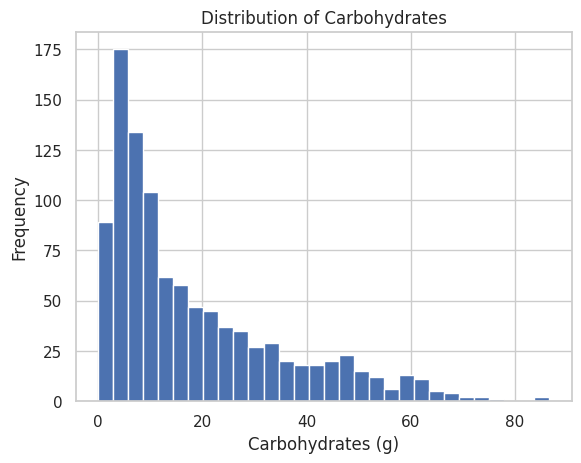

In [13]:
# Carbohydrates Distribution
plt.figure()
plt.hist(nutri_df['Carbohydrates (g)'], bins=30)
plt.title("Distribution of Carbohydrates")
plt.xlabel("Carbohydrates (g)")
plt.ylabel("Frequency")
plt.show()

## 🍚 Carbohydrates
- Most dishes between **5–30g carbs**
- Clear carb-heavy nature of Indian cuisine
- Some dishes exceed **60–80g carbs**

In [14]:
# Correlation Matrix
correlation = nutri_df.corr(numeric_only=True)
print("\nCorrelation Matrix:\n")
display(correlation)



Correlation Matrix:



,Calories (kcal),Carbohydrates (g),Protein (g),Fats (g),Free Sugar (g),Fibre (g),Sodium (mg),Calcium (mg),Iron (mg),Vitamin C (mg),Folate (µg)
Calories (kcal),1.000000,0.225926,-0.018079,0.921712,0.090673,0.034743,-0.168387,-0.077906,0.032676,-0.202691,-0.110131
Carbohydrates (g),0.225926,1.000000,0.136422,-0.152554,0.765213,0.203843,-0.155183,0.055052,0.205253,-0.278824,-0.267540
Protein (g),-0.018079,0.136422,1.000000,-0.109697,-0.094466,0.280093,0.296879,0.407861,0.401453,-0.130990,0.006041
Fats (g),0.921712,-0.152554,-0.109697,1.000000,-0.180071,-0.064641,-0.030745,-0.125890,-0.054087,-0.102138,-0.023365
Free Sugar (g),0.090673,0.765213,-0.094466,-0.180071,1.000000,-0.086110,-0.138334,0.033388,-0.013175,-0.221282,-0.254773
Fibre (g),0.034743,0.203843,0.280093,-0.064641,-0.086110,1.000000,0.045157,0.445879,0.795138,0.007677,0.061279
Sodium (mg),-0.168387,-0.155183,0.296879,-0.030745,-0.138334,0.045157,1.000000,0.075165,0.232973,0.024680,0.006559
Calcium (mg),-0.077906,0.055052,0.407861,-0.125890,0.033388,0.445879,0.075165,1.000000,0.538005,-0.048511,0.027822
Iron (mg),0.032676,0.205253,0.401453,-0.054087,-0.013175,0.795138,0.232973,0.538005,1.000000,-0.044355,0.024490
Vitamin C (mg),-0.202691,-0.278824,-0.130990,-0.102138,-0.221282,0.007677,0.024680,-0.048511,-0.044355,1.000000,0.651761


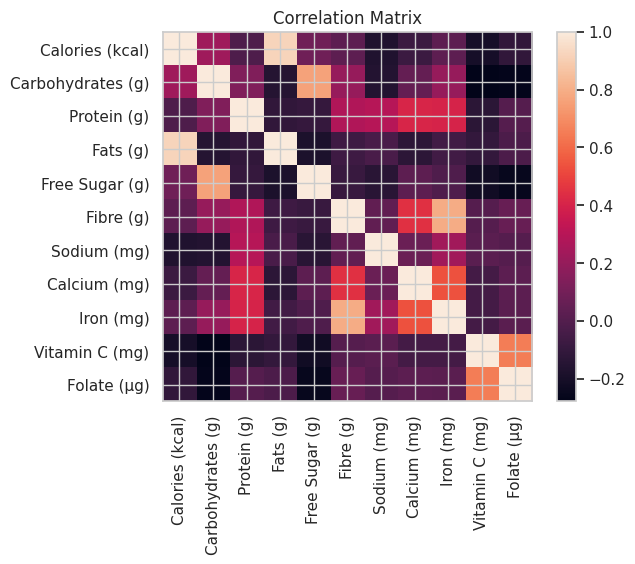

In [15]:
# Correlation Heatmap
plt.figure()
plt.imshow(correlation)
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()

# 🔗 Correlation Insights

## Strong Positive Correlations
- **Calories & Fats** → very strong correlation  
- **Calories & Carbohydrates** → moderate correlation  
- **Iron & Calcium** → strong relationship  
- **Vitamin C & Folate** → strong correlation  

## Weak / Negative Correlations
- Free Sugar has weak relationship with most nutrients  
- Sodium not strongly tied to calories 

In [16]:
# Top 5 High Calorie Foods
top_calories = nutri_df.sort_values("Calories (kcal)", ascending=False)[["Dish Name", "Calories (kcal)"]].head()
print("\nTop 5 High Calorie Foods:\n")
display(top_calories)



Top 5 High Calorie Foods:



,Dish Name,Calories (kcal)
414,Soyabean muthias,839.33
416,Soyabean namak paras,838.46
351,Masala vada,826.02
339,Mathri,805.12
420,Rice moong dal cheela (Chawal aur moong dal ka...,798.26


In [17]:
# Top 5 High Protein Foods
top_protein = nutri_df.sort_values("Protein (g)", ascending=False)[["Dish Name", "Protein (g)"]].head()
print("\nTop 5 High Protein Foods:\n")
display(top_protein)


Top 5 High Protein Foods:



,Dish Name,Protein (g)
683,Gun powder chutney,21.55
539,Roast chicken,20.49
849,Lemon chicken,20.20
930,Maa chaane ki dal,19.80
1013,Bengal 5 Spice Blend (Panch Phoran),18.26


# 🎯 Key Insights

- **Fats are the strongest predictor of calories**  
- **Carbohydrates also contribute significantly**  
- **Micronutrients tend to cluster together**

In [18]:
# Data Cleaning

nutri_df['Vitamin C (mg)'].fillna(nutri_df['Vitamin C (mg)'].median(), inplace=True)
nutri_df['Folate (µg)'].fillna(nutri_df['Folate (µg)'].median(), inplace=True)

/tmp/ipykernel_17/1033984441.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nutri_df['Vitamin C (mg)'].fillna(nutri_df['Vitamin C (mg)'].median(), inplace=True)
/tmp/ipykernel_17/1033984441.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me